# Tabular Kaggle Project — American Express Default Prediction  

**Dataset:** [American Express - Default Prediction](https://www.kaggle.com/competitions/amex-default-prediction/data)

## Project Goal 
  
This is a binary classification problem from a Kaggle competition hosted by American Express. The goal is to predict whether a customer will default on their credit card balance based on their monthly credit card statement data. The goal of this classification project is to predict whether a customer will default in the future using historical monthly customer profile features.

- `target = 0`: customer did not default
- `target = 1`: customer defaulted

## Files used in this notebook

- `sample_train_data.csv`: monthly customer records  
- `sample_labels.csv`: target labels
- `test_sample_100k.csv`: sampled subset of the test data used for prediction 

## Important: 

In this dataset, one customer can appear in multiple rows because each row represents one monthly statement and the negative class has been subsampled for this dataset at 5%, and thus receives a 20x weighting in the scoring metric. Features are anonymized and normalized, and fall into the following general categories:

D_* = Delinquency variables

S_* = Spend variables

P_* = Payment variables

B_* = Balance variables

R_* = Risk variables

### 1. Data Loading and Initial Look

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score, roc_curve)

In [4]:
# Load the data
train = pd.read_csv("sample_train_data.csv")
labels = pd.read_csv("sample_labels.csv")

# Check data dimensions
print(f"Train data shape: {train.shape}")
print(f"Labels shape: {labels.shape}")

Train data shape: (10000, 190)
Labels shape: (458913, 2)


In [64]:
# Review first few rows
print("\nTrain Data (first 5 rows)")
display(train.head(5))

print("\nLabels (first 5 rows)")
display(labels.head(5))


Train Data (first 5 rows)


,customer_ID,S_2,P_2,D_39,B_1,B_2,R_1,S_3,D_41,B_3,...,D_136,D_137,D_138,D_139,D_140,D_141,D_142,D_143,D_144,D_145
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-03-09,0.938469,0.001733,0.008724,1.006838,0.009228,0.124035,0.008771,0.004709,...,NaN,NaN,NaN,0.002427,0.003706,0.003818,NaN,0.000569,0.000610,0.002674
1,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-04-07,0.936665,0.005775,0.004923,1.000653,0.006151,0.126750,0.000798,0.002714,...,NaN,NaN,NaN,0.003954,0.003167,0.005032,NaN,0.009576,0.005492,0.009217
2,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-05-28,0.954180,0.091505,0.021655,1.009672,0.006815,0.123977,0.007598,0.009423,...,NaN,NaN,NaN,0.003269,0.007329,0.000427,NaN,0.003429,0.006986,0.002603
3,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-06-13,0.960384,0.002455,0.013683,1.002700,0.001373,0.117169,0.000685,0.005531,...,NaN,NaN,NaN,0.006117,0.004516,0.003200,NaN,0.008419,0.006527,0.009600
4,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,2017-07-16,0.947248,0.002483,0.015193,1.000727,0.007605,0.117325,0.004653,0.009312,...,NaN,NaN,NaN,0.003671,0.004946,0.008889,NaN,0.001670,0.008126,0.009827



Labels (first 5 rows)


,customer_ID,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0


In [7]:
# Count the number of rows (data points) and features

# Number of unique customers
n_customers = train['customer_ID'].nunique()
print(f"Unique customers: {n_customers}")

# Average rows per customer
avg_rows = train.shape[0] / n_customers
print(f"Avg rows per customer: {avg_rows:.1f}")

# List all features
print(f"\nTotal features: {train.shape[1]}")
print(f"Column list:\n{train.columns.tolist()}")

Unique customers: 826
Avg rows per customer: 12.1

Total features: 190
Column list:
['customer_ID', 'S_2', 'P_2', 'D_39', 'B_1', 'B_2', 'R_1', 'S_3', 'D_41', 'B_3', 'D_42', 'D_43', 'D_44', 'B_4', 'D_45', 'B_5', 'R_2', 'D_46', 'D_47', 'D_48', 'D_49', 'B_6', 'B_7', 'B_8', 'D_50', 'D_51', 'B_9', 'R_3', 'D_52', 'P_3', 'B_10', 'D_53', 'S_5', 'B_11', 'S_6', 'D_54', 'R_4', 'S_7', 'B_12', 'S_8', 'D_55', 'D_56', 'B_13', 'R_5', 'D_58', 'S_9', 'B_14', 'D_59', 'D_60', 'D_61', 'B_15', 'S_11', 'D_62', 'D_63', 'D_64', 'D_65', 'B_16', 'B_17', 'B_18', 'B_19', 'D_66', 'B_20', 'D_68', 'S_12', 'R_6', 'S_13', 'B_21', 'D_69', 'B_22', 'D_70', 'D_71', 'D_72', 'S_15', 'B_23', 'D_73', 'P_4', 'D_74', 'D_75', 'D_76', 'B_24', 'R_7', 'D_77', 'B_25', 'B_26', 'D_78', 'D_79', 'R_8', 'R_9', 'S_16', 'D_80', 'R_10', 'R_11', 'B_27', 'D_81', 'D_82', 'S_17', 'R_12', 'B_28', 'R_13', 'D_83', 'R_14', 'R_15', 'D_84', 'R_16', 'B_29', 'B_30', 'S_18', 'D_86', 'D_87', 'R_17', 'R_18', 'D_88', 'B_31', 'S_19', 'R_19', 'B_32', 'S_20', 

In [47]:
# Count missing values per column
missing = train.isnull().sum()
missing_pct = (train.isnull().sum() / len(train) * 100).round(2)

# Create summary table
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

# Show only columns with missing values
display(missing_df[missing_df['Missing Count'] > 0])

,Missing Count,Missing %
D_87,9990,99.90
D_88,9980,99.80
D_111,9975,99.75
D_110,9975,99.75
B_39,9972,99.72
...,...,...
S_26,2,0.02
D_109,2,0.02
D_112,2,0.02
S_23,1,0.01


In [48]:
# Define categorical and numerical variables
cat_features = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117',
                'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
num_features = [c for c in train.columns
                if c not in cat_features + ['customer_ID', 'S_2']]

# CATEGORICAL
cat_rows = []
for feat in cat_features:
    unique_vals = train[feat].dropna().unique()
    n_missing = train[feat].isnull().sum()
    pct_missing = (n_missing / len(train) * 100)

    cat_rows.append({
        'Feature': feat,
        'Type': 'Categorical',
        'Values': ', '.join(map(str, sorted(unique_vals))),
        'Missing Count': n_missing,
        'Missing %': round(pct_missing, 1)
    })

cat_summary_df = pd.DataFrame(cat_rows)

print("=== CATEGORICAL FEATURES ===")
display(
    cat_summary_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]}
    ])
)

# NUMERICAL

print("\n\n=== NUMERICAL FEATURES ===")
summary_rows = []
for feat in num_features:
    col = train[feat]
    n_missing = col.isnull().sum()
    pct_missing = (n_missing / len(train) * 100)
    mean_val = col.mean()
    std_val = col.std()
    min_val = col.min()
    max_val = col.max()

    lower = mean_val - 3 * std_val
    upper = mean_val + 3 * std_val
    n_outliers = ((col < lower) | (col > upper)).sum()

    summary_rows.append({
        'Feature': feat,
        'Type': 'Numerical',
        'Min': round(min_val, 3) if not pd.isna(min_val) else 'N/A',
        'Max': round(max_val, 3) if not pd.isna(max_val) else 'N/A',
        'Missing': f"{n_missing} ({pct_missing:.1f}%)",
        'Outliers (3std)': n_outliers
    })

summary_df = pd.DataFrame(summary_rows)

display(summary_df)

=== CATEGORICAL FEATURES ===


,Feature,Type,Values,Missing Count,Missing %
0,B_30,Categorical,"0.0, 1.0, 2.0",0,0.000000
1,B_38,Categorical,"1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0",0,0.000000
2,D_114,Categorical,"0.0, 1.0",294,2.900000
3,D_116,Categorical,"0.0, 1.0",294,2.900000
4,D_117,Categorical,"-1.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0",294,2.900000
5,D_120,Categorical,"0.0, 1.0",294,2.900000
6,D_126,Categorical,"-1.0, 0.0, 1.0",200,2.000000
7,D_63,Categorical,"CL, CO, CR, XL, XM, XZ",0,0.000000
8,D_64,Categorical,"-1, O, R, U",344,3.400000
9,D_66,Categorical,"0.0, 1.0",8867,88.700000




=== NUMERICAL FEATURES ===


,Feature,Type,Min,Max,Missing,Outliers (3std)
0,P_2,Numerical,-0.257,1.010,64 (0.6%),42
1,D_39,Numerical,0.000,4.268,0 (0.0%),111
2,B_1,Numerical,-0.141,1.323,0 (0.0%),266
3,B_2,Numerical,0.000,1.010,0 (0.0%),0
4,R_1,Numerical,0.000,2.259,0 (0.0%),293
...,...,...,...,...,...,...
172,D_141,Numerical,0.000,1.113,153 (1.5%),0
173,D_142,Numerical,-0.009,1.186,8428 (84.3%),18
174,D_143,Numerical,0.000,1.010,153 (1.5%),0
175,D_144,Numerical,0.000,1.342,63 (0.6%),341


target
0    340085
1    118828
Name: count, dtype: int64


Proportions:


target
0    0.7411
1    0.2589
Name: proportion, dtype: float64


Imbalance ratio: 2.86 : 1

After AMEX weighting
Weighted class 0: 6801700
Weighted class 1: 118828
Weighted ratio: 57.24 : 1


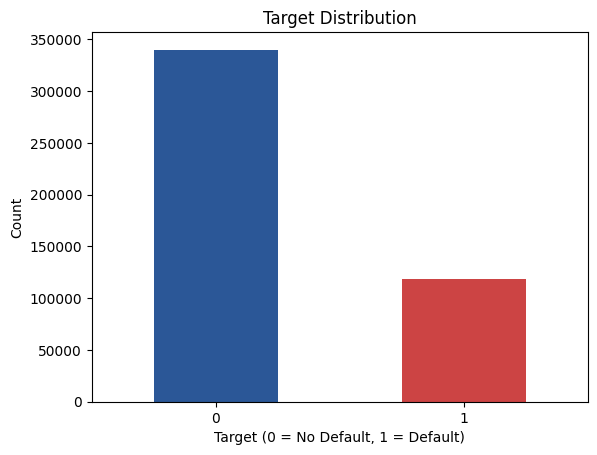

In [49]:
# Target distribution
display(labels['target'].value_counts())

print(f"\nProportions:")
display(labels['target'].value_counts(normalize=True).round(4))

# Imbalance ratio
n_class0 = (labels['target'] == 0).sum()
n_class1 = (labels['target'] == 1).sum()

print(f"\nImbalance ratio: {n_class0/n_class1:.2f} : 1")

# AMEX adjustment
# Negative class (0) is subsampled to 5% → weight = 20x
weighted_class0 = n_class0 * 20
weighted_class1 = n_class1

print("\nAfter AMEX weighting")
print(f"Weighted class 0: {weighted_class0}")
print(f"Weighted class 1: {weighted_class1}")
print(f"Weighted ratio: {weighted_class0/weighted_class1:.2f} : 1")

# Plot
labels['target'].value_counts().plot(kind='bar', color=['#2b5797', '#cc4444'])
plt.title('Target Distribution')
plt.xlabel('Target (0 = No Default, 1 = Default)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [50]:
# Separate numerical and categorical features
cat_features = ['B_30', 'B_38', 'D_114', 'D_116', 'D_117',
                'D_120', 'D_126', 'D_63', 'D_64', 'D_66', 'D_68']
num_features = [c for c in train.columns
                if c not in cat_features + ['customer_ID', 'S_2']]

# Aggregate numerical: mean, std, min, max, last
num_agg = train.groupby('customer_ID')[num_features].agg(
    ['mean', 'std', 'min', 'max', 'last']
)
num_agg.columns = ['_'.join(col) for col in num_agg.columns]

# Aggregate categorical: last value, nunique
cat_agg = train.groupby('customer_ID')[cat_features].agg(['last', 'nunique'])
cat_agg.columns = ['_'.join(col) for col in cat_agg.columns]

# Combine all and merge with labels
train_agg = pd.concat([num_agg, cat_agg], axis=1).reset_index()
train_agg = train_agg.merge(labels, on='customer_ID', how='left')

print(f"Shape after aggregation: {train_agg.shape}")
print(f"Each customer now has 1 row")
display(train_agg.head())

Shape after aggregation: (826, 909)
Each customer now has 1 row


,customer_ID,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last,D_39_mean,D_39_std,D_39_min,D_39_max,...,D_126_nunique,D_63_last,D_63_nunique,D_64_last,D_64_nunique,D_66_last,D_66_nunique,D_68_last,D_68_nunique,target
0,0000099d6bd597052cdcda90ffabf56573fe9d7c79be5f...,0.933824,0.024194,0.868580,0.960384,0.934745,0.010704,0.024444,0.001082,0.091505,...,1,CR,1,O,1,NaN,0,6.0,1,0
1,00000fd6641609c6ece5454664794f0340ad84dddce9a2...,0.899820,0.022119,0.861109,0.929122,0.880519,0.215205,0.199150,0.002224,0.567403,...,1,CO,1,O,1,NaN,0,6.0,1,0
2,00001b22f846c82c51f6e3958ccd81970162bae8b007e8...,0.878454,0.028911,0.797670,0.904482,0.880875,0.004181,0.002758,0.000802,0.009704,...,1,CO,1,R,1,NaN,0,6.0,1,0
3,000041bdba6ecadd89a52d11886e8eaaec9325906c9723...,0.598969,0.020108,0.567442,0.623392,0.621776,0.048862,0.088466,0.000660,0.268476,...,1,CO,1,O,1,NaN,0,3.0,3,0
4,00007889e4fcd2614b6cbe7f8f3d2e5c728eca32d9eb8a...,0.891679,0.042325,0.805045,0.940382,0.871900,0.004644,0.002882,0.000030,0.008680,...,1,CO,1,O,1,1.0,1,6.0,1,0


### 2. Data Visualization

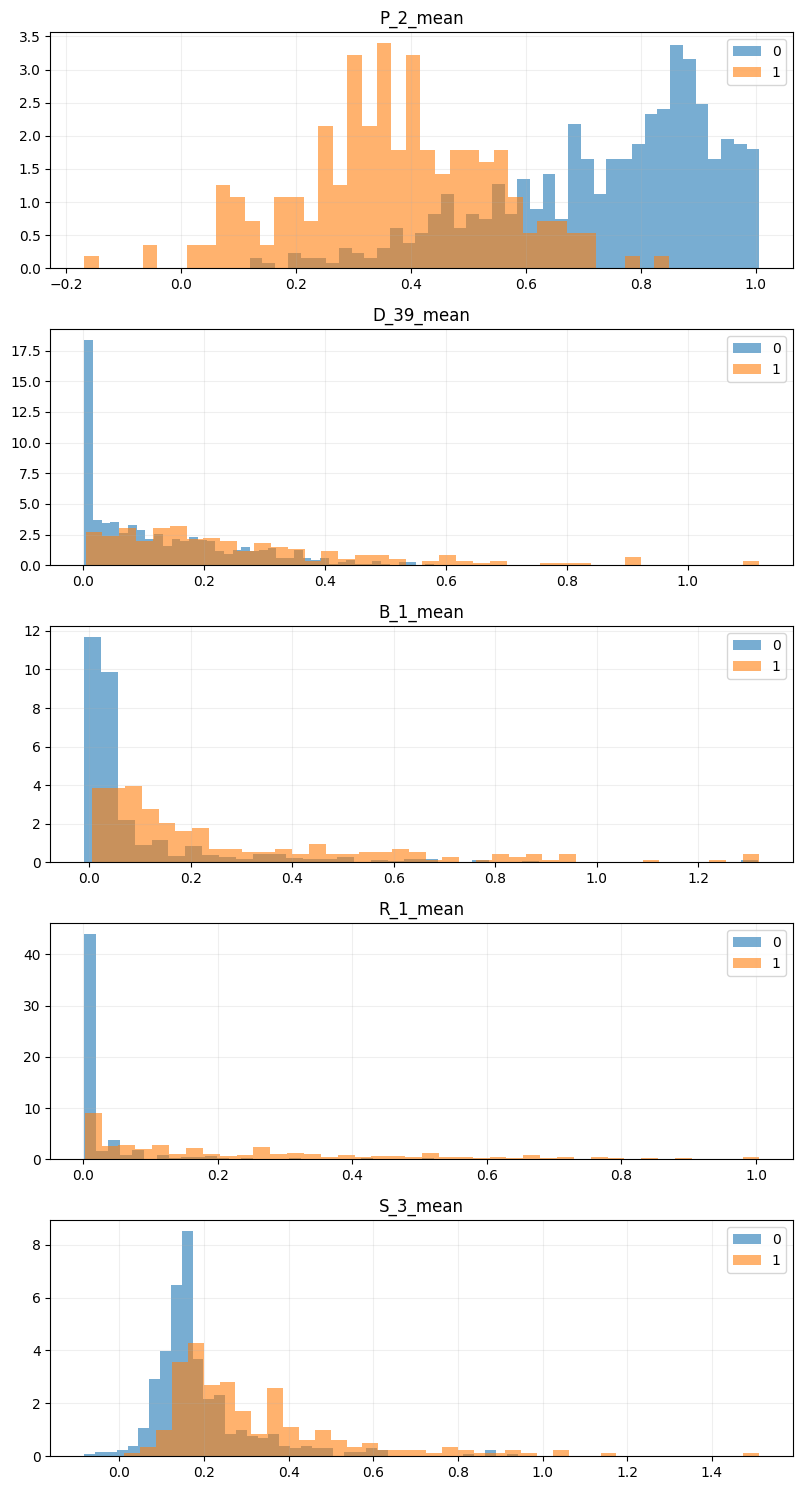

In [51]:
# Select some important features to plot
features_to_plot = ['P_2_mean', 'D_39_mean', 'B_1_mean',
                    'R_1_mean', 'S_3_mean']

fig, axes = plt.subplots(len(features_to_plot), 1,
                         figsize=(8, 3*len(features_to_plot)))

for i, feat in enumerate(features_to_plot):
    axes[i].hist(
        train_agg[train_agg['target']==0][feat].dropna(),
        bins=40, alpha=0.6,
        label='0', density=True
    )
    
    axes[i].hist(
        train_agg[train_agg['target']==1][feat].dropna(),
        bins=40, alpha=0.6,
        label='1', density=True
    )

    axes[i].set_title(feat)
    axes[i].legend()
    axes[i].grid(alpha=0.2)

plt.tight_layout()
plt.show()

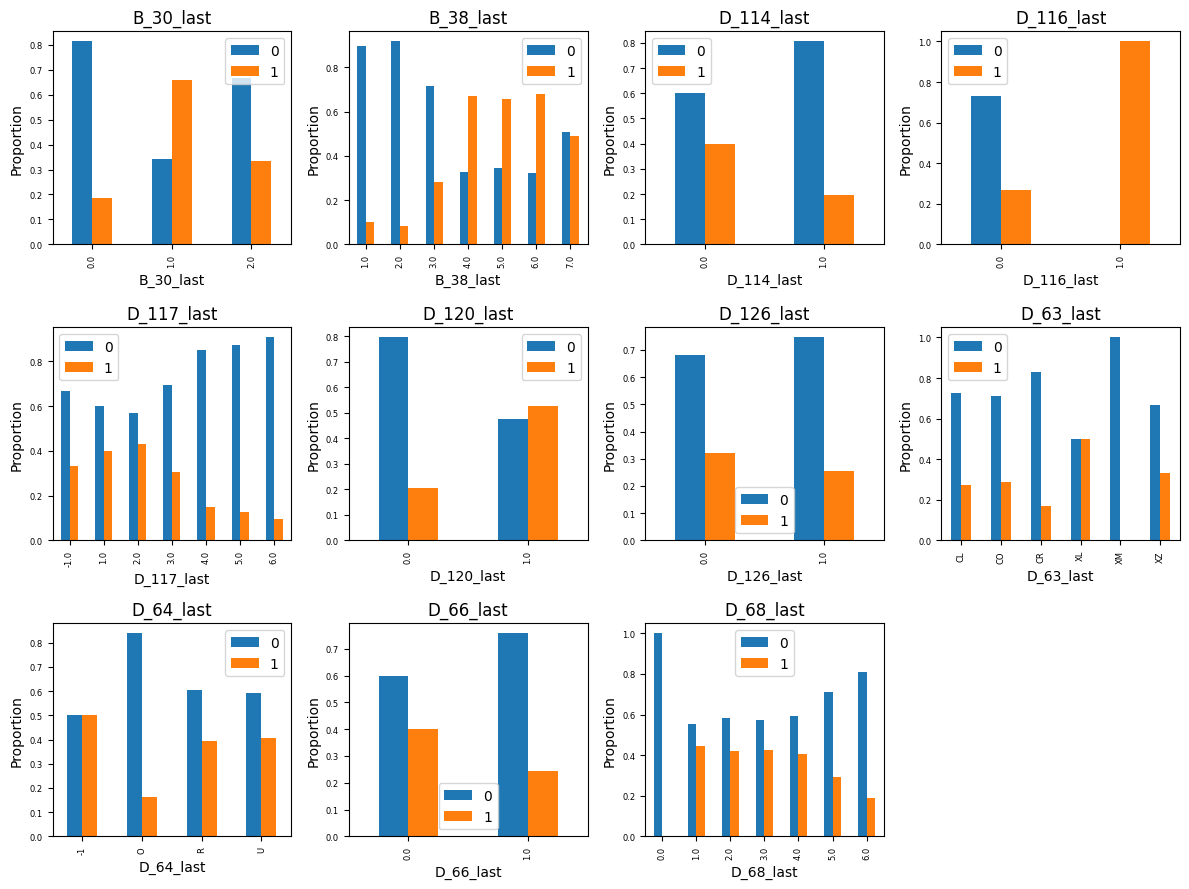

In [52]:
# Plot bar charts for categorical features
cat_last_cols = [f'{c}_last' for c in cat_features]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))
axes = axes.flatten()

for i, feat in enumerate(cat_last_cols):
    if feat not in train_agg.columns:
        continue
    # Calculate proportions by class
    ct = pd.crosstab(train_agg[feat], train_agg['target'], normalize='index')
    ct.plot(kind='bar', ax=axes[i])
    axes[i].set_title(feat)
    axes[i].set_ylabel('Proportion')
    axes[i].legend(['0', '1'])
    axes[i].tick_params(labelsize=6)

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

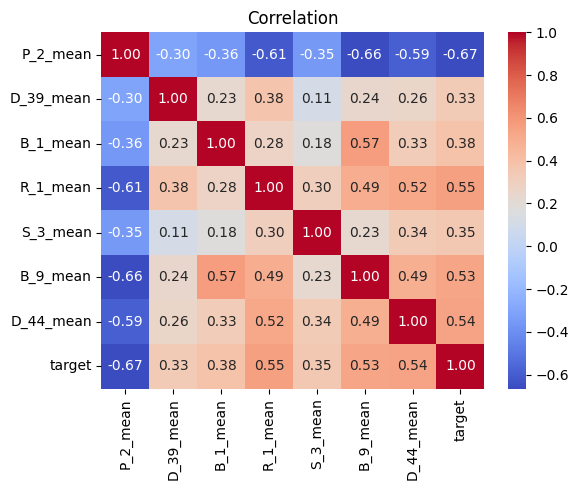

In [53]:
# Plot correlation heatmap between key features and target
key_features = ['P_2_mean', 'D_39_mean', 'B_1_mean', 'R_1_mean',
                'S_3_mean', 'B_9_mean', 'D_44_mean', 'target']

corr_matrix = train_agg[key_features].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation')
plt.tight_layout()
plt.show()

In [55]:
# Handle missing values for numerical columns
num_cols = train_agg.select_dtypes(include='number').columns.drop('target')
train_agg[num_cols] = train_agg[num_cols].fillna(train_agg[num_cols].median())

# Handle missing values for categorical columns (using mode)
cat_last_cols = [f'{c}_last' for c in cat_features]
for col in cat_last_cols:
    if col in train_agg.columns:
        train_agg[col] = train_agg[col].fillna(train_agg[col].mode()[0])

# Verify: any missing left?
print(f"Total remaining missing: "
      f"{train_agg.isnull().sum().sum()}")

Total remaining missing: 0


In [56]:
# Rescaling với StandardScaler for Logistic Regression

scaler = StandardScaler()

# Save values before scaling for comparison
before_scale = train_agg[num_cols].describe().loc[['mean', 'std']].round(2)
print("BEFORE scaling:")
display(before_scale.iloc[:, :5])  # show first 5 cols

# Apply scaler
train_agg[num_cols] = scaler.fit_transform(train_agg[num_cols])

after_scale = train_agg[num_cols].describe().loc[['mean', 'std']].round(2)
print("\nAFTER scaling:")
display(after_scale.iloc[:, :5])
# mean ~ 0, std ~ 1 for all columns

BEFORE scaling:


,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last
mean,0.64,0.05,0.56,0.71,0.63
std,0.25,0.04,0.28,0.22,0.27



AFTER scaling:


,P_2_mean,P_2_std,P_2_min,P_2_max,P_2_last
mean,0.0,-0.0,0.0,-0.0,0.0
std,1.0,1.0,1.0,1.0,1.0


In [57]:
# One-hot encode the 'last' columns of categorical features
cat_last_cols = [f'{c}_last' for c in cat_features]

# Check column count before
print(f"Columns BEFORE one-hot: {train_agg.shape[1]}")

train_agg = pd.get_dummies(train_agg, columns=cat_last_cols, drop_first=True)

# Check column count after
print(f"Columns AFTER one-hot: {train_agg.shape[1]}")

Columns BEFORE one-hot: 909
Columns AFTER one-hot: 931


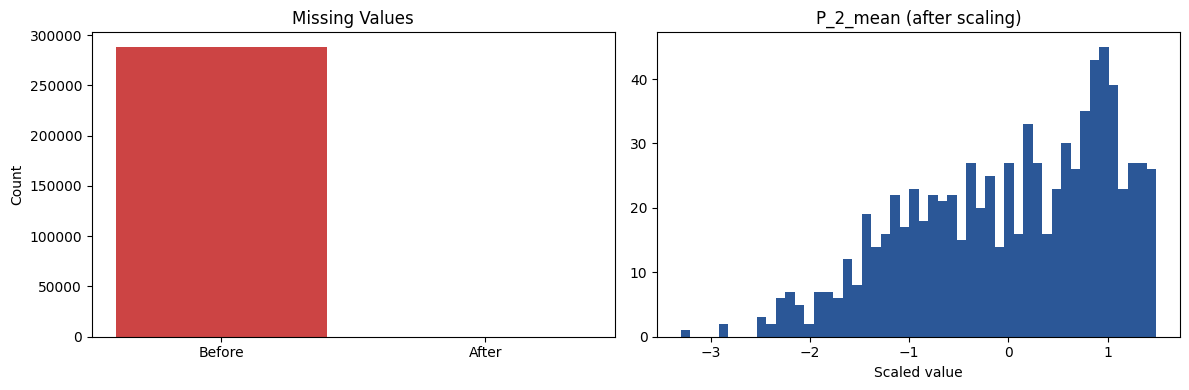

In [58]:
# Compare distributions before and after processing
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Before: missing distribution
missing_before = train.isnull().sum().sum()
missing_after = train_agg.isnull().sum().sum()
axes[0].bar(['Before', 'After'],
            [missing_before, missing_after],
            color=['#cc4444', '#2b9757'])
axes[0].set_title('Missing Values')
axes[0].set_ylabel('Count')

# After: distribution of 1 scaled feature
if 'P_2_mean' in train_agg.columns:
    axes[1].hist(train_agg['P_2_mean'].dropna(), bins=50, color='#2b5797')
    axes[1].set_title('P_2_mean (after scaling)')
    axes[1].set_xlabel('Scaled value')

plt.tight_layout()
plt.show()

In [59]:
# Remove unnecessary columns
X = train_agg.drop(columns=['customer_ID', 'target'])
y = train_agg['target']

# Save median from train for test
train_medians_for_test = X.median(numeric_only=True)

print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Target distribution:\n{y.value_counts()}")

# Split data: 60% train, 20% val, 20% test
# Step 1: Separate 20% test first
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 2: From remaining 80%, take 25% = 20% overall for validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f"\nTrain: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Val:   {X_val.shape[0]} samples ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:  {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Number of features: 929
Number of samples: 826
Target distribution:
target
0    604
1    222
Name: count, dtype: int64

Train: 495 samples (60%)
Val:   165 samples (20%)
Test:  166 samples (20%)


In [60]:
# Initialize model with basic hyperparameters
model = GradientBoostingClassifier(
    n_estimators=200,     # Number of trees
    max_depth=5,          # Maximum depth
    learning_rate=0.1,    # Learning rate
    subsample=0.8,        # Sample 80% per tree
    random_state=42       # Ensure reproducibility
)

# AMEX note:
# Negative class (target = 0) was subsampled at 5%,
# so negative samples receive 20x weight in the scoring metric.

w_train = y_train.map({0: 20, 1: 1})

print("Sample weight distribution:")
print(w_train.value_counts())

# Train
print("Training model")
model.fit(X_train, y_train, sample_weight=w_train)
print("Done")

Sample weight distribution:
target
20    362
1     133
Name: count, dtype: int64
Training model
Done


CLASSIFICATION REPORT
                precision    recall  f1-score   support

No Default (0)       0.83      0.95      0.89       121
   Default (1)       0.78      0.48      0.59        44

      accuracy                           0.82       165
     macro avg       0.81      0.71      0.74       165
  weighted avg       0.82      0.82      0.81       165

Weighted AUC-ROC Score: 0.8892


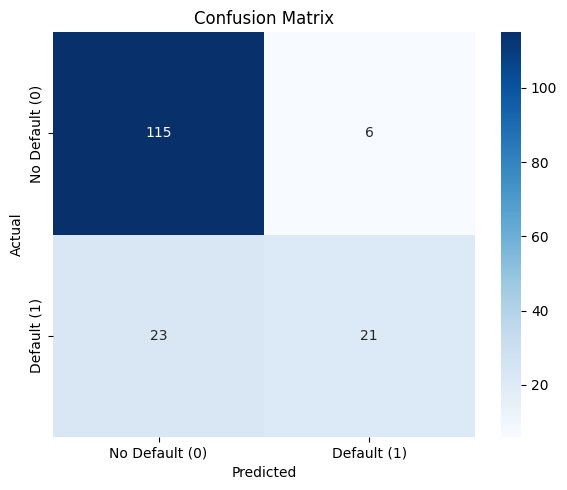

In [61]:
# Predict on validation set
y_pred = model.predict(X_val)
y_prob = model.predict_proba(X_val)[:, 1]

# Weight for validation according to AMEX note
w_val = y_val.map({0: 20, 1: 1})

# Print classification report
print("CLASSIFICATION REPORT")
print(classification_report(
    y_val,
    y_pred,
    target_names=['No Default (0)', 'Default (1)']
))

# Weighted AUC-ROC
auc_score = roc_auc_score(y_val, y_prob, sample_weight=w_val)
print(f"Weighted AUC-ROC Score: {auc_score:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Default (0)', 'Default (1)'],
            yticklabels=['No Default (0)', 'Default (1)'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

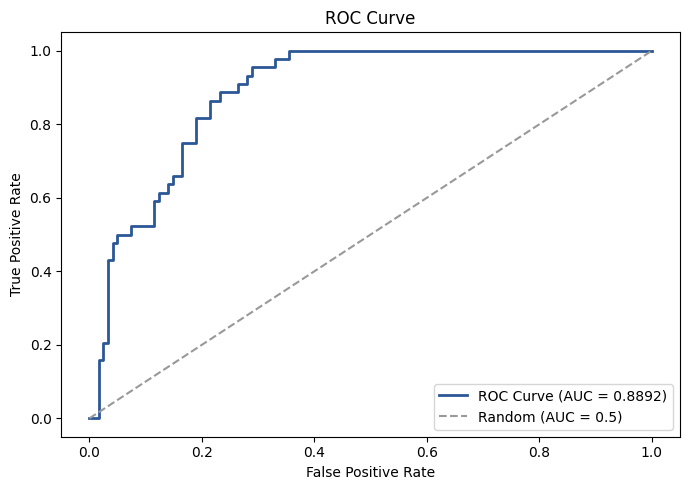

In [62]:
# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_val, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#2b5797', linewidth=2,
         label=f'ROC Curve (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='#999999', linestyle='--',
         label='Random (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
# Load and process test data exactly like train
test = pd.read_csv('test_sample_100k.csv')
test_customer_ids = test['customer_ID'].unique()

# Aggregate same as train
test_num_agg = test.groupby('customer_ID')[num_features].agg(
    ['mean', 'std', 'min', 'max', 'last']
)
test_num_agg.columns = ['_'.join(col) for col in test_num_agg.columns]

test_cat_agg = test.groupby('customer_ID')[cat_features].agg(['last', 'nunique'])
test_cat_agg.columns = ['_'.join(col) for col in test_cat_agg.columns]

test_agg = pd.concat([test_num_agg, test_cat_agg], axis=1).reset_index()


# Handle missing, encode, scale same as train
# Missing values
test_num_cols = [c for c in num_cols if c in test_agg.columns]

# Select only the columns that are present in both test_agg and train_medians_for_test
valid_num_cols = [c for c in test_num_cols if c in train_medians_for_test.index]

test_agg[valid_num_cols] = test_agg[valid_num_cols].fillna(
    train_medians_for_test[valid_num_cols]
)

# One-hot encode
test_cat_last_cols = [f'{c}_last' for c in cat_features]
for col in test_cat_last_cols:
    if col in test_agg.columns:
        test_agg[col] = test_agg[col].fillna(test_agg[col].mode()[0])

test_agg = pd.get_dummies(test_agg, columns=test_cat_last_cols, drop_first=True)

# Ensure same columns as train
# Add missing columns (= 0), remove extra columns
for col in X.columns:
    if col not in test_agg.columns:
        test_agg[col] = 0
test_agg = test_agg[['customer_ID'] + list(X.columns)]

# Prepare final test features (no scaling applied)
X_test_final = test_agg.drop(columns=['customer_ID'])

# Ensure same feature order as training data
X_test_final = X_test_final[X_train.columns]

# Predict and create submission file
test_pred = model.predict_proba(X_test_final)[:, 1]

submission = pd.DataFrame({
    'customer_ID': test_agg['customer_ID'],
    'prediction': test_pred
})
submission.to_csv('submission.csv', index=False)

print(f"Created submission.csv with {len(submission)} rows")
display(submission.head())

Created submission.csv with 8156 rows


,customer_ID,prediction
0,479cef4833d7e5f54bd90b01d07d6f3383b335188ec2b3...,0.003904
1,479d06889f5b3f05c8f7aa6173ea2b48b1baee26ededf6...,0.917468
2,479d19b48e773dae4a3e82da07880d674909662840ef3e...,0.999973
3,479d1b60d47122567f75b6dc96abe05db70aca4efe5acc...,0.592927
4,479d20610b7df172eb0d93287c5678ea058fbc82242b7b...,0.835435
